In [33]:
# ==========================================================
# Project : AI-Powered Cybersecurity Log Analysis and Threat Detection
# Notebook: 02_Exploratory_Data_Analysis.ipynb
# Purpose : Exploratory Data Analysis (EDA)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Graph settings
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
#Load the Cleaned Dataset
df = pd.read_csv("cleaned_rba_dataset.csv")

In [35]:
#Check the first five rows:

df.head()

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,0,NaN,-4.320000e+18,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,NaN,-4.320000e+18,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,NaN,-3.280000e+18,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,NaN,-4.320000e+18,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,NaN,-4.620000e+18,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


In [36]:
#Basic Dataset Information
print("Dataset Shape :", df.shape)
print("\n")

print("Total Rows :", len(df))
print("Total Columns :", len(df.columns))

Dataset Shape : (30001, 16)


Total Rows : 30001
Total Columns : 16


In [37]:
#Total Login Attempts
total_logins = len(df)

print("Total Login Attempts :", total_logins)

Total Login Attempts : 30001


In [38]:
# Successful Logins
successful_logins = df["Login_Successful"].sum()

print("Successful Logins :", successful_logins)

Successful Logins : 15084


In [39]:
# Failed Logins
failed_logins = len(df) - successful_logins

print("Failed Logins :", failed_logins)

Failed Logins : 14917


In [40]:
# Attack IP Count
attack_ips = df["Is_Attack_IP"].sum()

print("Attack IP Records :", attack_ips)

Attack IP Records : 2723


In [41]:
# Account Takeover Count
account_takeover = df["Is_Account_Takeover"].sum()

print("Account Takeover Cases :", account_takeover)

Account Takeover Cases : 0


In [42]:
# Summary Table
summary = pd.DataFrame({

    "Metric":[
        "Total Login Attempts",
        "Successful Logins",
        "Failed Logins",
        "Attack IP Records",
        "Account Takeover Cases"
    ],

    "Count":[
        total_logins,
        successful_logins,
        failed_logins,
        attack_ips,
        account_takeover
    ]

})

summary

,Metric,Count
0,Total Login Attempts,30001
1,Successful Logins,15084
2,Failed Logins,14917
3,Attack IP Records,2723
4,Account Takeover Cases,0


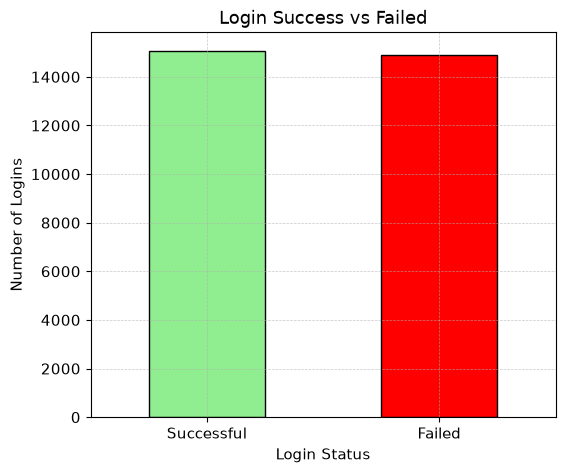

In [43]:
# Login Success vs Failed (First Chart)
login_counts = df["Login_Successful"].value_counts()

plt.figure(figsize=(6,5))

login_counts.plot(
    kind="bar",
    color=["lightgreen", "red"],
    edgecolor="black"
)

plt.title("Login Success vs Failed")
plt.xlabel("Login Status")
plt.ylabel("Number of Logins")

plt.xticks(
    ticks=[0,1],
    labels=["Successful","Failed"],
    rotation=0
)

# Show both horizontal and vertical grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.show()

In [44]:
#Device Type Distribution

device_counts = df["Device_Type"].value_counts()

print(device_counts)

Device_Type
mobile     20829
desktop     8167
tablet       975
unknown       15
bot           13
Name: count, dtype: int64


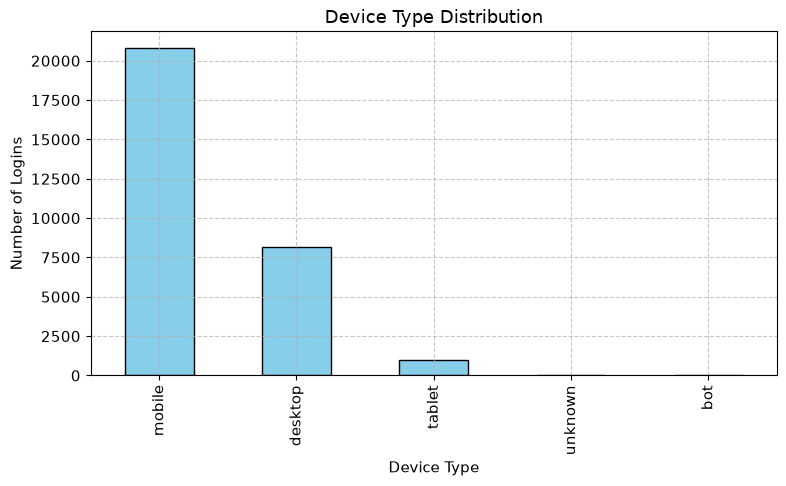

In [45]:
# Bar Chart
plt.figure(figsize=(8,5))

device_counts.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Number of Logins")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

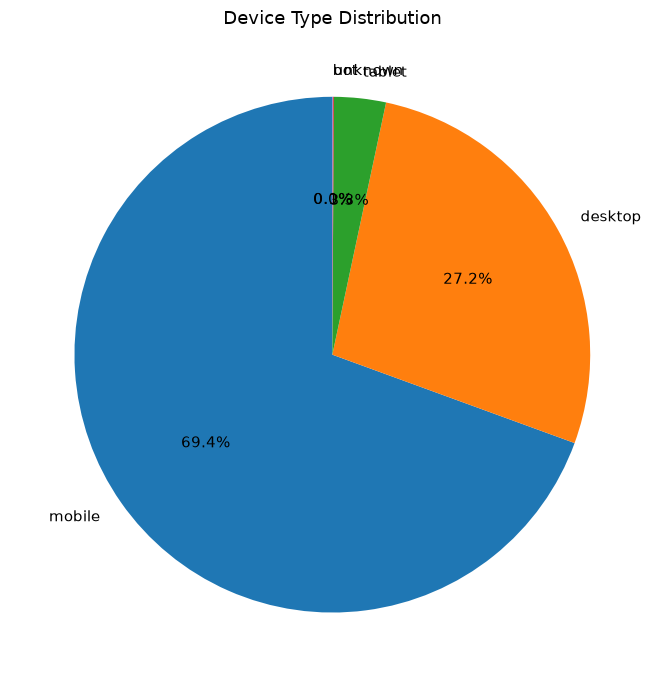

In [46]:
# Pie Chart (Optional)
plt.figure(figsize=(7,7))

device_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Device Type Distribution")

plt.ylabel("")

plt.tight_layout()

plt.show()

In [47]:
# Browser Distribution

browser_counts = df["Browser_Name_and_Version"].value_counts()

print(browser_counts.head(10))

Browser_Name_and_Version
Chrome Mobile WebView 85.0.4183    5421
Chrome 69.0.3497.17.19             4048
Android 2.3.3.2672                 3577
Firefox 20.0.0.1618                2265
Chrome Mobile WebView 80.0.3987    1067
Chrome 86.0.4202                    763
Chrome 72.0.3626.56                 690
Android 2.3.6                       635
Chrome Mobile 81.0.4044.1943        604
Chrome 79.0.3945.192.203            554
Name: count, dtype: int64


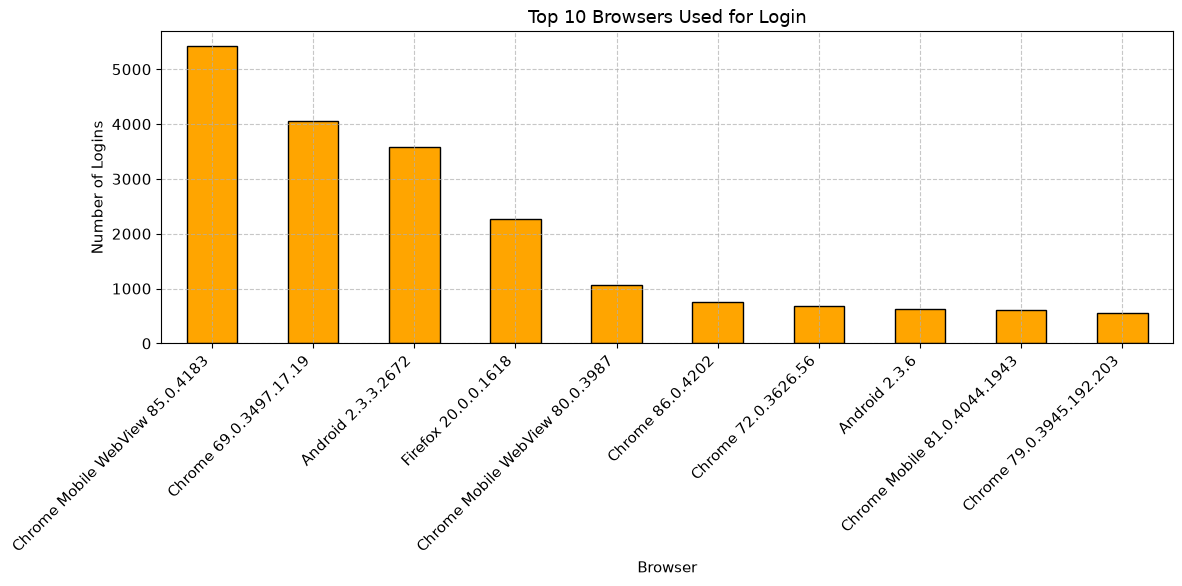

In [48]:
# Bar Chart
plt.figure(figsize=(12,6))

browser_counts.head(10).plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Top 10 Browsers Used for Login")
plt.xlabel("Browser")
plt.ylabel("Number of Logins")

plt.xticks(rotation=45, ha="right")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [49]:
# Operating System Distribution

os_counts = df["OS_Name_and_Version"].value_counts()

print(os_counts.head(10))

OS_Name_and_Version
iOS 11.2.6           5982
Mac OS X 10.14.6     5338
iOS 7.1              3900
Android 4.1          1700
Android 2.2          1424
iOS 13.4             1367
Android 6.0.99       1183
iOS 14.2.1           1097
Android 5.5.1         932
Windows Phone 8.1     616
Name: count, dtype: int64


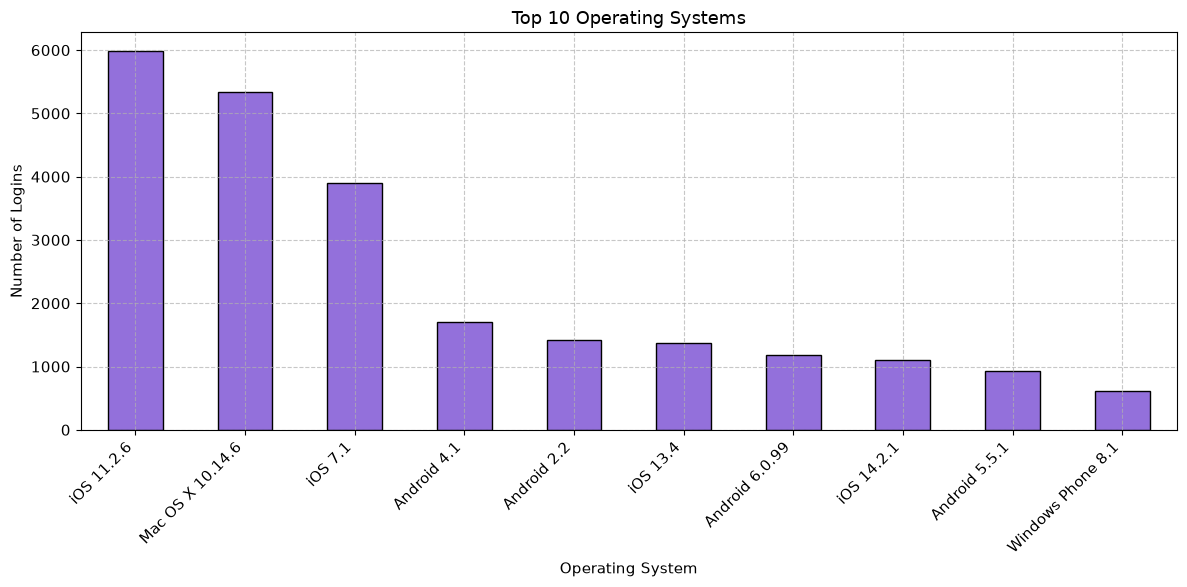

In [50]:
# Bar Chart
plt.figure(figsize=(12,6))

os_counts.head(10).plot(
    kind="bar",
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Top 10 Operating Systems")
plt.xlabel("Operating System")
plt.ylabel("Number of Logins")

plt.xticks(rotation=45, ha="right")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [51]:
# Country-wise Login Attempts
# Check the top countries
country_counts = df["Country_name"].value_counts()

print(country_counts.head(10))

Country_name
NO    15516
US     6269
PL     1492
BR     1486
IN      725
UA      656
DE      534
AU      382
FR      325
CZ      284
Name: count, dtype: int64


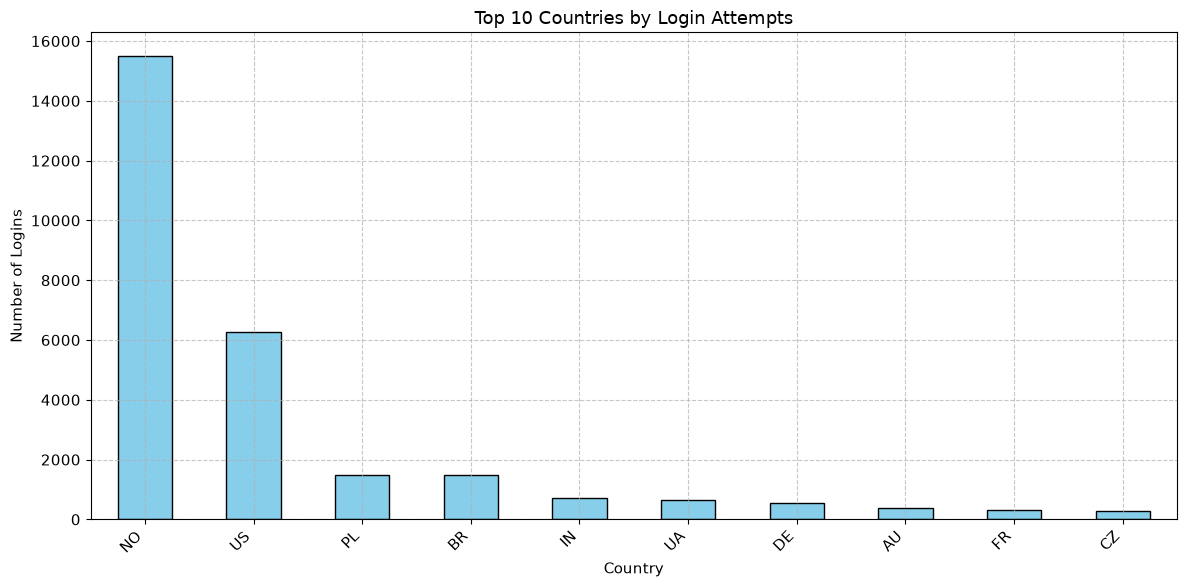

In [52]:
# Bar Chart
plt.figure(figsize=(12,6))

country_counts.head(10).plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Login Attempts")
plt.xlabel("Country")
plt.ylabel("Number of Logins")

plt.xticks(rotation=45, ha="right")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [53]:
# Region-wise Login Attempts
region_counts = df["Region"].value_counts()

print(region_counts.head(10))

Region
-                       12612
Oslo County              2734
Viken                    2412
Rogaland                 2003
Vestfold og Telemark      913
Innlandet                 880
Vestland                  817
Nordland                  564
Texas                     538
Mazovia                   524
Name: count, dtype: int64


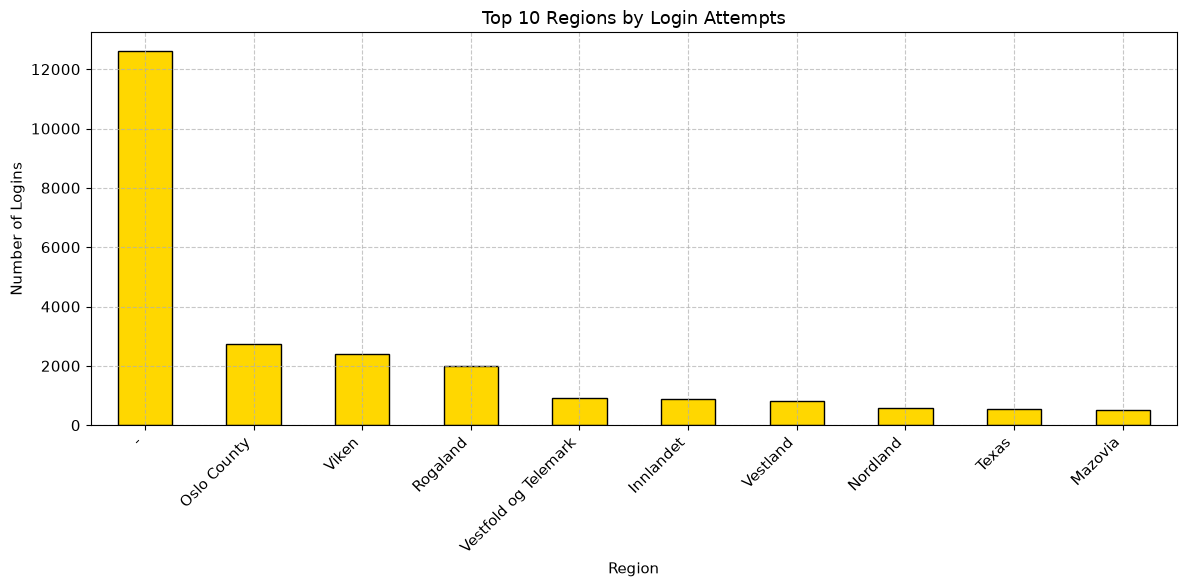

In [54]:
# Bar Chart
plt.figure(figsize=(12,6))

region_counts.head(10).plot(
    kind="bar",
    color="gold",
    edgecolor="black"
)

plt.title("Top 10 Regions by Login Attempts")
plt.xlabel("Region")
plt.ylabel("Number of Logins")

plt.xticks(rotation=45, ha="right")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

City
-              12502
Oslo            2732
Stavanger        633
Warsaw           485
Sandnes          390
Bergen           353
Drammen          332
Fredrikstad      235
Sandefjord       209
Dallas           205
Name: count, dtype: int64


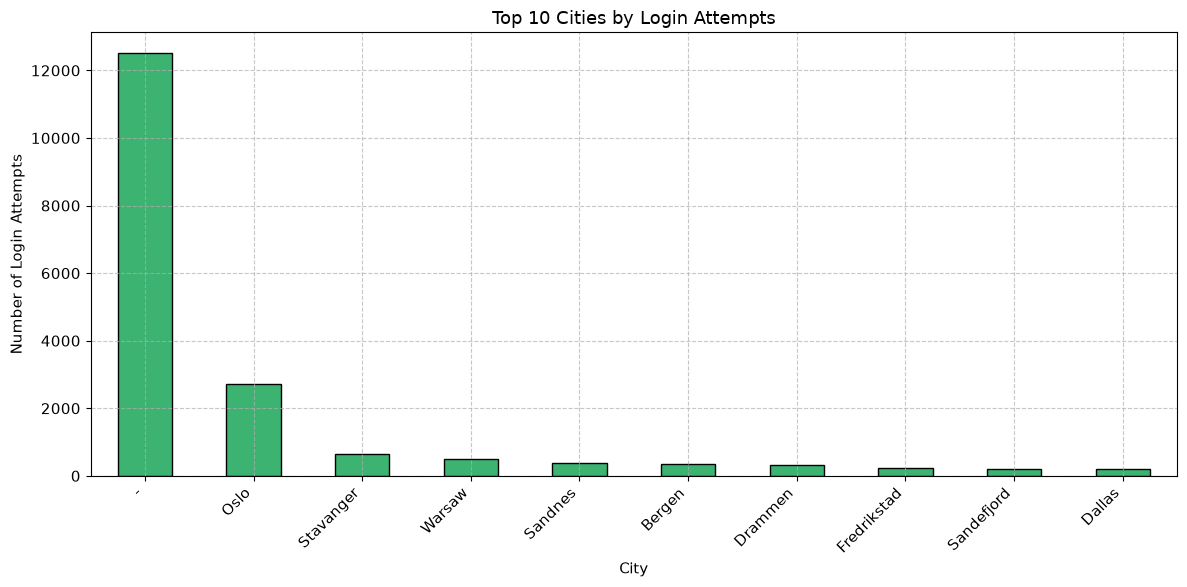

In [55]:
# 10 Cities by Login Attempts
# Count Login Attempts by City
city_counts = df["City"].value_counts()

print(city_counts.head(10))


# Bar Chart
plt.figure(figsize=(12,6))

city_counts.head(10).plot(
    kind="bar",
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Top 10 Cities by Login Attempts")
plt.xlabel("City")
plt.ylabel("Number of Login Attempts")

plt.xticks(rotation=45, ha="right")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

Login_Successful
True     50.278324
False    49.721676
Name: proportion, dtype: float64


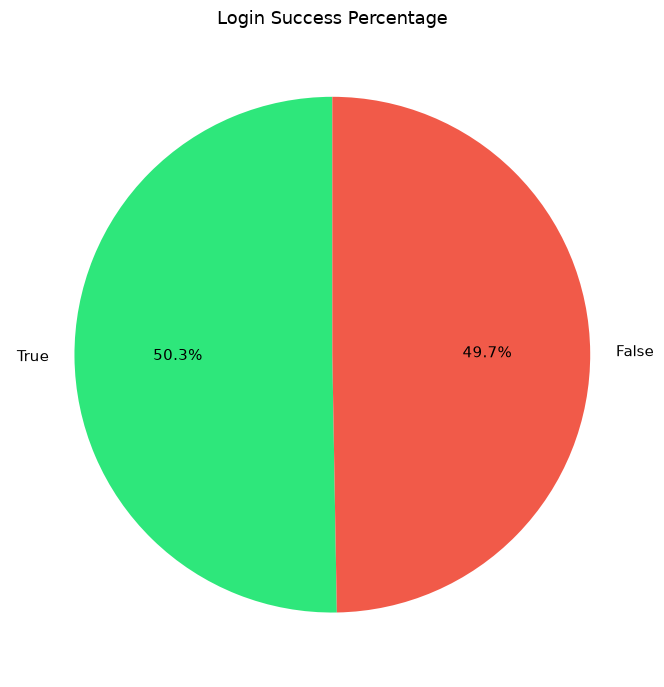

In [56]:
# Login Success Percentage
# Calculate Percentage
login_percentage = df["Login_Successful"].value_counts(normalize=True) * 100

print(login_percentage)

# Pie Chart
plt.figure(figsize=(7,7))

login_percentage.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#2EE77B", "#F15A49"],
    startangle=90
)

plt.title("Login Success Percentage")

plt.ylabel("")

plt.tight_layout()

plt.show()

Is_Attack_IP
False    27278
True      2723
Name: count, dtype: int64


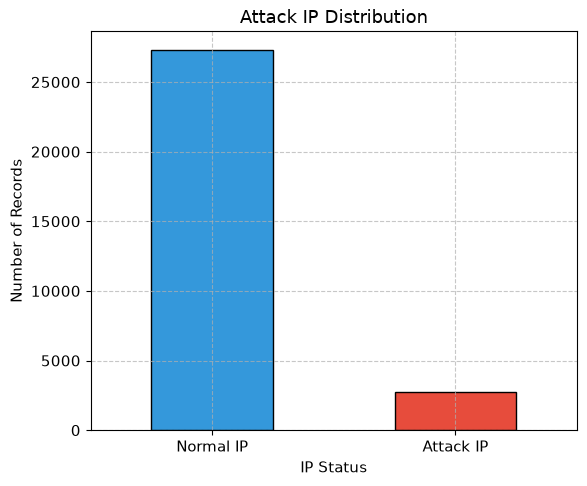

In [57]:
# Attack IP Distribution
# Count Attack IPs
attack_counts = df["Is_Attack_IP"].value_counts()

print(attack_counts)

# Bar Chart
plt.figure(figsize=(6,5))

attack_counts.plot(
    kind="bar",
    color=["#3498DB", "#E74C3C"],
    edgecolor="black"
)

plt.title("Attack IP Distribution")
plt.xlabel("IP Status")
plt.ylabel("Number of Records")

plt.xticks(
    ticks=[0,1],
    labels=["Normal IP","Attack IP"],
    rotation=0
)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

Is_Account_Takeover
False    30001
Name: count, dtype: int64


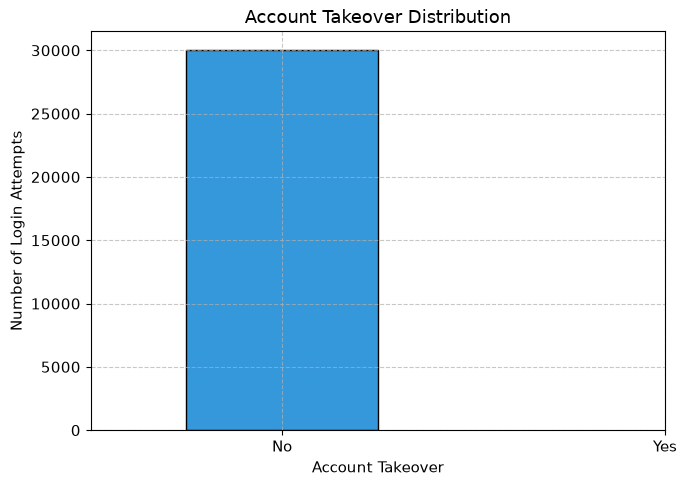

In [58]:
# Account Takeover Distribution
# Count Account Takeover Records
account_takeover_counts = df["Is_Account_Takeover"].value_counts()

print(account_takeover_counts)

# Bar Chart
plt.figure(figsize=(7,5))

account_takeover_counts.plot(
    kind="bar",
    color=["#3498DB", "#E74C3C"],
    edgecolor="black"
)

plt.title("Account Takeover Distribution")
plt.xlabel("Account Takeover")
plt.ylabel("Number of Login Attempts")

plt.xticks(
    ticks=[0,1],
    labels=["No","Yes"],
    rotation=0
)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

count     1462.000000
mean       699.446648
std       1209.437790
min         10.000000
25%        472.000000
50%        542.000000
75%        694.750000
max      34284.000000
Name: Round_Trip_Time_ms, dtype: float64


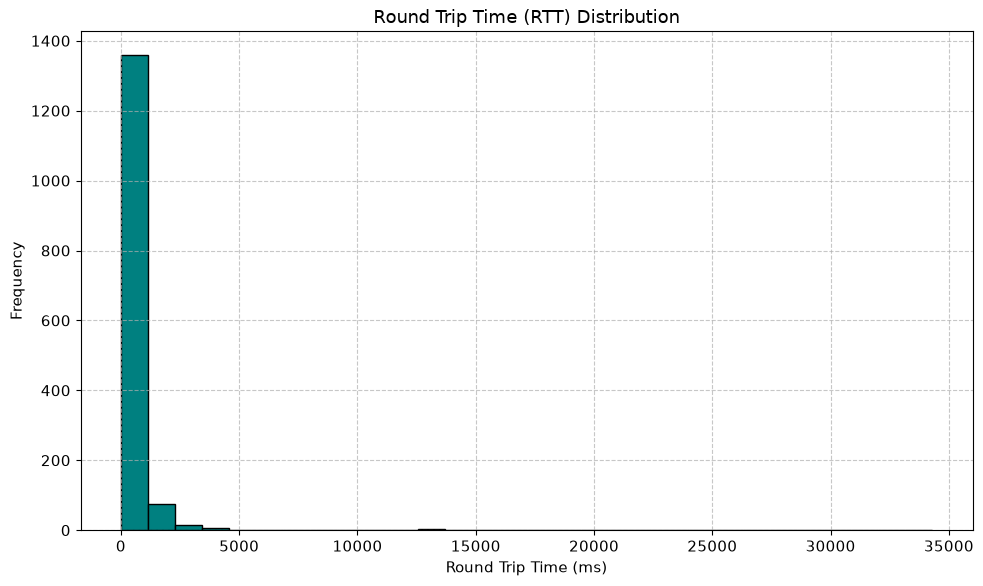

In [59]:
# Round Trip Time (RTT) Analysis
# Statistics
print(df["Round_Trip_Time_ms"].describe())

# Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df["Round_Trip_Time_ms"],
    bins=30,
    color="teal",
    edgecolor="black"
)

plt.title("Round Trip Time (RTT) Distribution")
plt.xlabel("Round Trip Time (ms)")
plt.ylabel("Frequency")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Autonomous_System_Number_ASN
29695     9612
393398    5123
41164     1627
29492      957
15659      913
205727     703
57963      326
11427      316
60117      297
25400      287
Name: count, dtype: int64


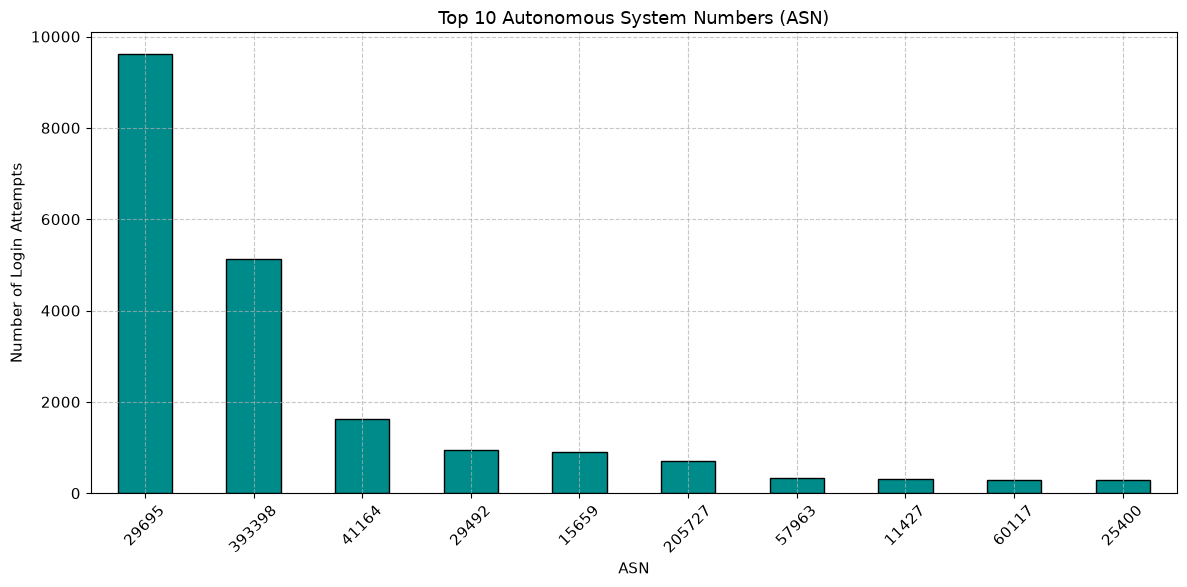

In [60]:
# Top 10 Autonomous System Numbers (ASN)
# Count Top ASN
asn_counts = df["Autonomous_System_Number_ASN"].value_counts().head(10)

print(asn_counts)

# Bar Chart
plt.figure(figsize=(12,6))

asn_counts.plot(
    kind="bar",
    color="darkcyan",
    edgecolor="black"
)

plt.title("Top 10 Autonomous System Numbers (ASN)")
plt.xlabel("ASN")
plt.ylabel("Number of Login Attempts")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Login_Successful  False  True 
Device_Type                   
bot                  13      0
desktop            2790   5377
mobile            11703   9126
tablet              400    575
unknown               9      6


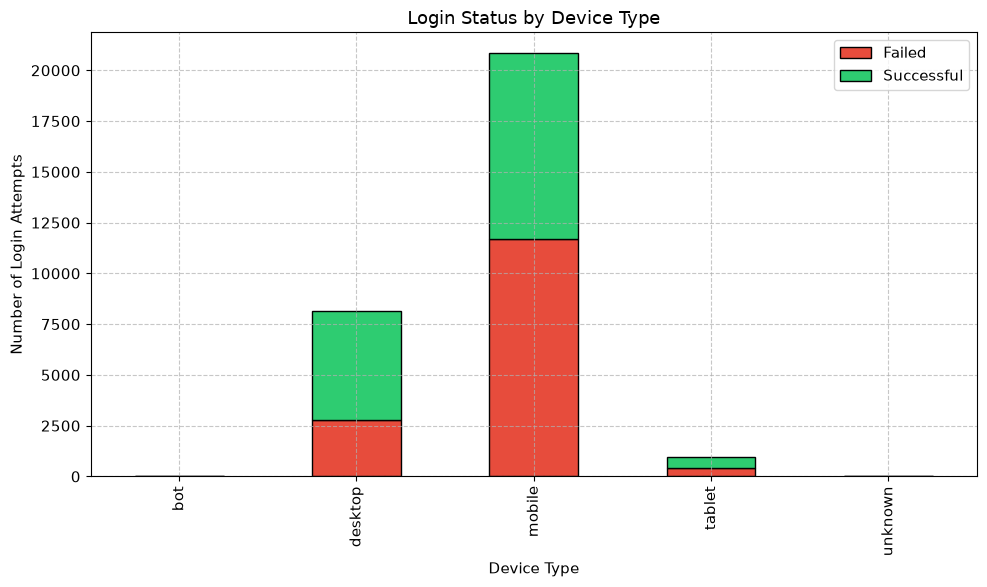

In [61]:
# Login Status by Device Type
# Crosstab
device_login = pd.crosstab(
    df["Device_Type"],
    df["Login_Successful"]
)

print(device_login)

# Stacked Bar Chart
device_login.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#E74C3C", "#2ECC71"],
    edgecolor="black"
)

plt.title("Login Status by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Login Attempts")

plt.legend(["Failed","Successful"])

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Login_Successful  False  True 
Country_name                  
AF                    1      0
AM                    3      0
AO                    2      0
AR                   85      3
AT                    1      0
AU                  269    113
BA                    3      0
BD                   82      5
BE                    9      3
BF                    5      1


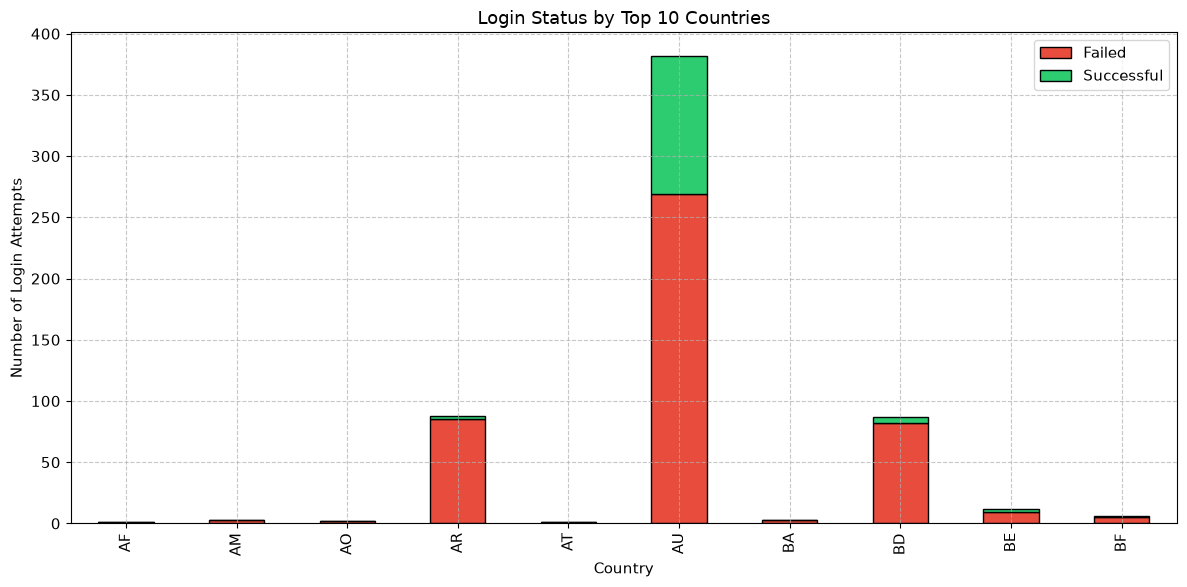

In [62]:
# Login Status by Country
# Crosstab
country_login = pd.crosstab(
    df["Country_name"],
    df["Login_Successful"]
)

print(country_login.head(10))

# Stacked Bar Chart
country_login.head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#E74C3C", "#2ECC71"],
    edgecolor="black"
)

plt.title("Login Status by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Login Attempts")

plt.legend(["Failed","Successful"])

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

                              Record_ID   User_ID  Round_Trip_Time_ms  \
Record_ID                      1.000000  0.000750            0.002391   
User_ID                        0.000750  1.000000           -0.035283   
Round_Trip_Time_ms             0.002391 -0.035283            1.000000   
Autonomous_System_Number_ASN  -0.062504 -0.066053            0.073591   
Login_Successful               0.014683  0.309320           -0.046263   
Is_Attack_IP                  -0.017319 -0.033246            0.013520   
Is_Account_Takeover                 NaN       NaN                 NaN   

                              Autonomous_System_Number_ASN  Login_Successful  \
Record_ID                                        -0.062504          0.014683   
User_ID                                          -0.066053          0.309320   
Round_Trip_Time_ms                                0.073591         -0.046263   
Autonomous_System_Number_ASN                      1.000000         -0.175910   
Login_Successfu

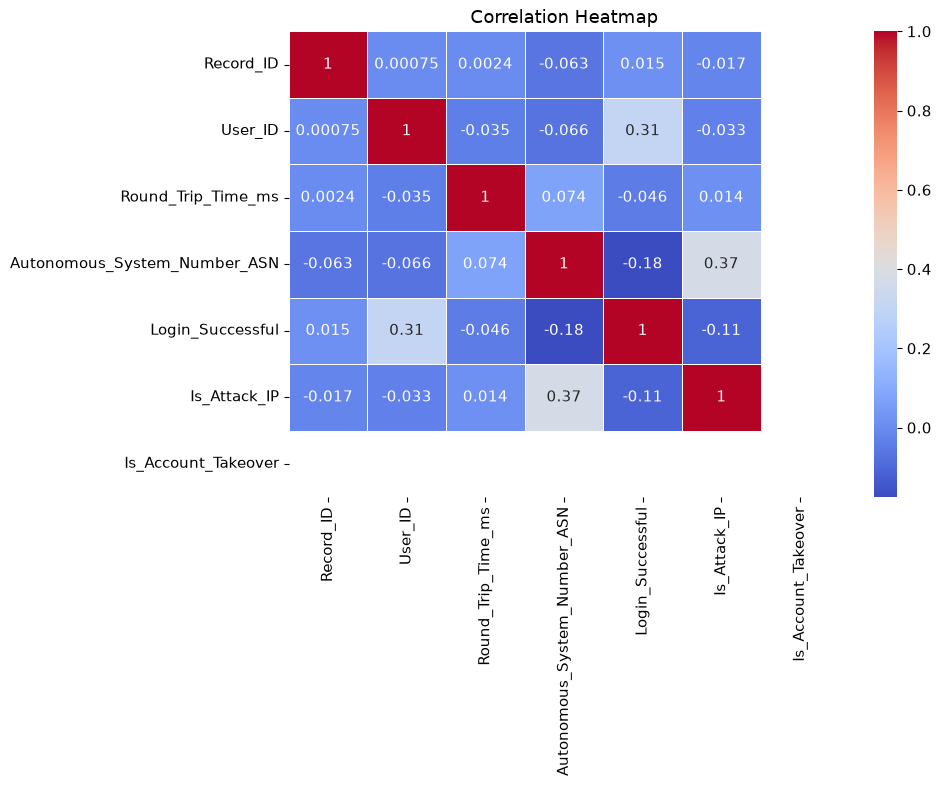

In [63]:
# Correlation Heatmap
# Select Numeric Columns
numeric_df = df.select_dtypes(include=["number", "bool"])

# Correlation Matrix
corr = numeric_df.corr()

print(corr)

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [64]:
# Final EDA Summary
print("="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"Total Records               : {len(df)}")
print(f"Successful Logins           : {df['Login_Successful'].sum()}")
print(f"Failed Logins               : {len(df)-df['Login_Successful'].sum()}")
print(f"Attack IP Records           : {df['Is_Attack_IP'].sum()}")
print(f"Account Takeover Cases      : {df['Is_Account_Takeover'].sum()}")

print("="*60)
print("EDA Completed Successfully!")
print("="*60)

EXPLORATORY DATA ANALYSIS SUMMARY
Total Records               : 30001
Successful Logins           : 15084
Failed Logins               : 14917
Attack IP Records           : 2723
Account Takeover Cases      : 0
EDA Completed Successfully!
